# Práctica 16: Comunicación con periféricos

Integrar rutinas y herramientas que permitan la comunicación entre una computadora y algún sistema externo es una cualidad muy deseable en una herramienta computacional que integra una cantidad considerable de rutinas y funciones destinadas a realizar operaciones con conjunto de datos. La comunicación entre la computadora y el mundo que la rodea se realiza por medio de dispositivos llamados periféricos, los cuales a su vez se conectan físicamente con la computadora mediante diferentes conectores especializados que a su vez intercambian datos usando protocolos específicos como el USB, WiFi, ethertnet, HDMI entre otros. La adquisición de datos es una parte fundametal de la práctica de la ingeniería, en actividades como la validación de modelos matemáticos o el análisis de la información que se puede extraer de las mediciones de un fenómeno.

En esta práctica trataremos con la adquisición de datos usando periféricos conectados a la computadora, entre el universo de posibilidades, haremos adqusición de imágenes usando una cámara web disponible en la computadora o una cámara ip de libre acceso. analizaremos la posibilidad de obtener información de sensores conectados a microcontroladores de bajo costo que usaremos como tarjetas de adquisición de datos.

## Visualización y captura de imágenes desde cámaras

En la práctica 13 hicimos algunas operaciones básicas con imágenes almacenadas en el disco duro o descargadas desde algún repositorio de internet como GitHub. Es muy sencillo adquirir una imágen usando una cámara para procesarla con herramioentas y métodos identicos a los expuetos en la práctica 13. Veremos dos formas posibles de acceder a las imágenes en una cámara, usando una dirección ip en el caso de las cámaras conectadas a la misma red que se encuentra conectada nuestra computadora y que, por supuesto, tengan un acceso a su imagen de forma libre y legal. La segunda manera de obtener una imagen es usando el hardware conectado a nuestra computadora, usando el puerto USB o bien, en el caso de las laptops, la cámara web integrada al equipo. Para poder hacer uso de las rutinas que veremos en esta práctica, es necesario instalar las siguientes apps, usado la ventana de Add ons en la página principal de  MATLAB®, en donde se deben buscar e instalar los siguientes paquetes:

* MATLAB Support Package for IP Cameras: `matlab.internal.addons.showAddon('USBWEBCAM');`
* MATLAB Support Package for USB Webcams: `matlab.internal.addons.showAddon('ML_IP_CAMERAS');`

Una vez instalados los paquetes necesarios para el uso de las cámaras, podemos hacer uso de ellas para obtener imágenes para procesar o almacenar. Para acceder a la imagen de una cámara web que este conectada en red, se hace uso del protocolo TCP-IP para capturar la imagen. En internet existen algunos repositorios que ofrecen acceso a cámaras ip, por ejemplo:

https://github.com/fury999io/public-ip-cams

Tomaremos una de las direcciones ip de alguna de las cámaras disponibles en el siguiente código:


camara = 
  ipcam with properties:

         URL: 'http://185.108.19.197:10800/axis-cgi/mjpg/video.cgi'
    Username: ''
    Password: ''
     Timeout: 10

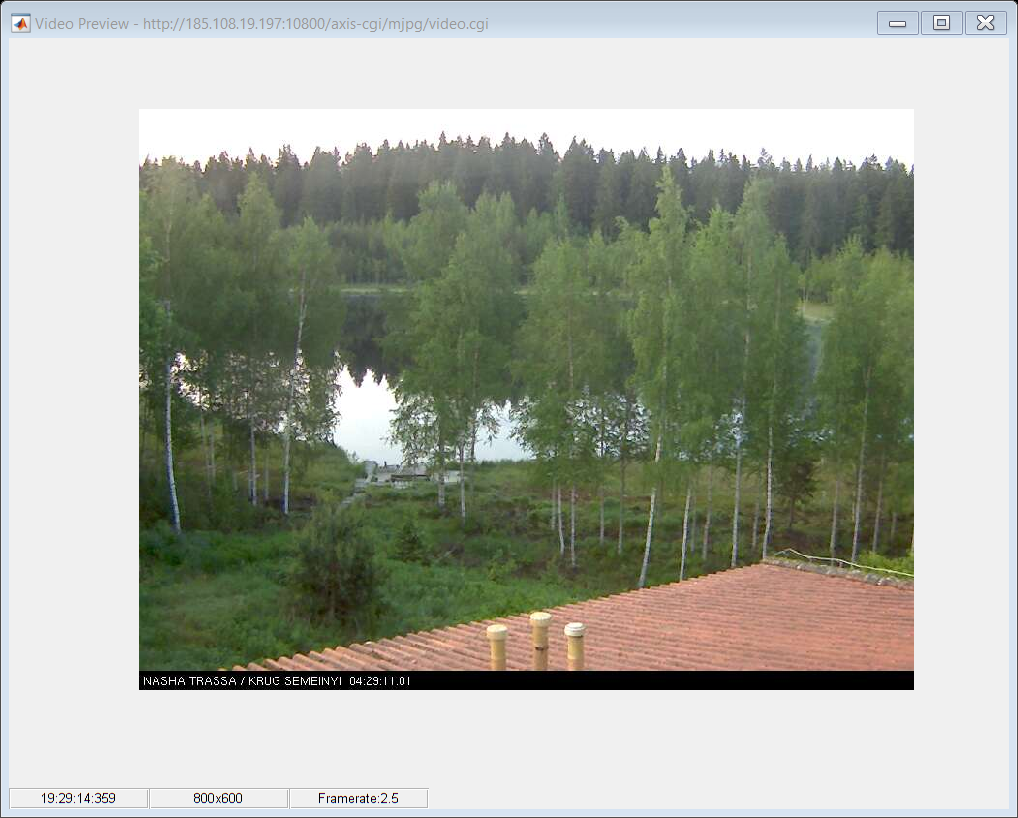

In [6]:
% Programa para acceder a una cámara ip de libre acceso, usando el paquete de soporte 
% para cámaras web
% Limpieza de variables e inicialización del espacio de trabajo
clear
close all
clc
% Se guarda la imagen de la cámara ip en un objeto llamado cámara
camara = ipcam('http://185.108.19.197:10800/axis-cgi/mjpg/video.cgi')
% Se muesta la imagen obtenida de la cámara
preview(camara)

Para ontener una fotografía usando la cámara ip se usa el comando `snapshot()`, como se muestra a continuación:

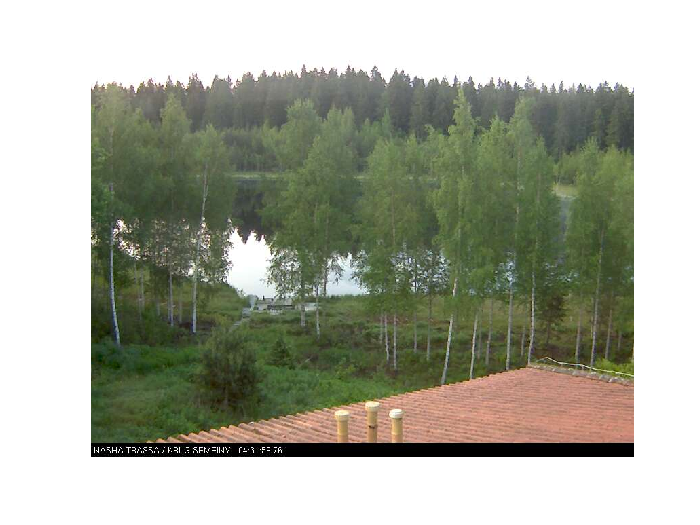

In [7]:
% Se cierra la vista previa de la cámara
closePreview(camara)
% Se hace la captura y se guarda en una variable llamada imagen
imagen = snapshot(camara);
% Se muestra la imagen de forma normal como en el caso de las imágenes 
% importadas desde archivos
imshow(imagen)

Todas las operaciones con imágenes estudiadas en la práctica 13 son válidas para la captura obtenida con este método. A continuación se muestra la descomposición en formato HSI de la captura obtenida con las instrucciones anteriores:

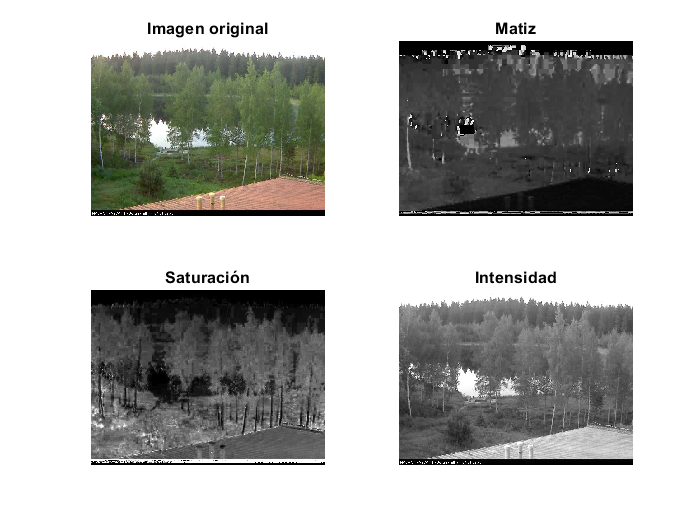

In [8]:
% Descomposición de la captura obtenida con la cámara ip 
HSI=rgb2hsv(imagen);
figure
subplot(2,2,1)
imshow(imagen)
title("Imagen original")
subplot(2,2,2)
imshow(HSI(:,:,1))
title("Matiz")
subplot(2,2,3)
imshow(HSI(:,:,2))
title("Saturación")
subplot(2,2,4)
imshow(HSI(:,:,3))
title("Intensidad")
clear('camara_web')

Para hacer uso de la cámara web o usb conectada de manera directa en nuestra computadora, haremos uso del paquete USB Webcams. Primero, se puede consultar el identificador de las cámara disponibles usando el comando webcamlist

In [24]:
clear
close all
clc
webcamlist

ans = 2x1 cell array
    {'HP True Vision FHD Camera'}
    {'Logitech StreamCam'       }

Seleccionamos alguna de las cámaras para obtener la imagen con las siguientes instrucciones:

In [25]:
camara_web=webcam('Logitech StreamCam')

camara_web = 
  webcam with properties:

                     Name: 'Logitech StreamCam'
               Resolution: '640x480'
     AvailableResolutions: {'2304x1296'  '1920x1080'  '1600x896'  '1280x720'  '960x540'  '848x480'  '640x480'  '640x360'  '424x240'  '320x240'  '176x144'}
    BacklightCompensation: 0
               Brightness: 128
                 Contrast: 128
                 Exposure: -5
             ExposureMode: 'auto'
                    Focus: 100
                FocusMode: 'auto'
                     Gain: 255
                      Pan: 0
                     Roll: 0
               Saturation: 128
                Sharpness: 128
                     Tilt: 0
             WhiteBalance: 3329
         WhiteBalanceMode: 'auto'
                     Zoom: 100

Generamos una vista previa como en el caso de la cámara ip:

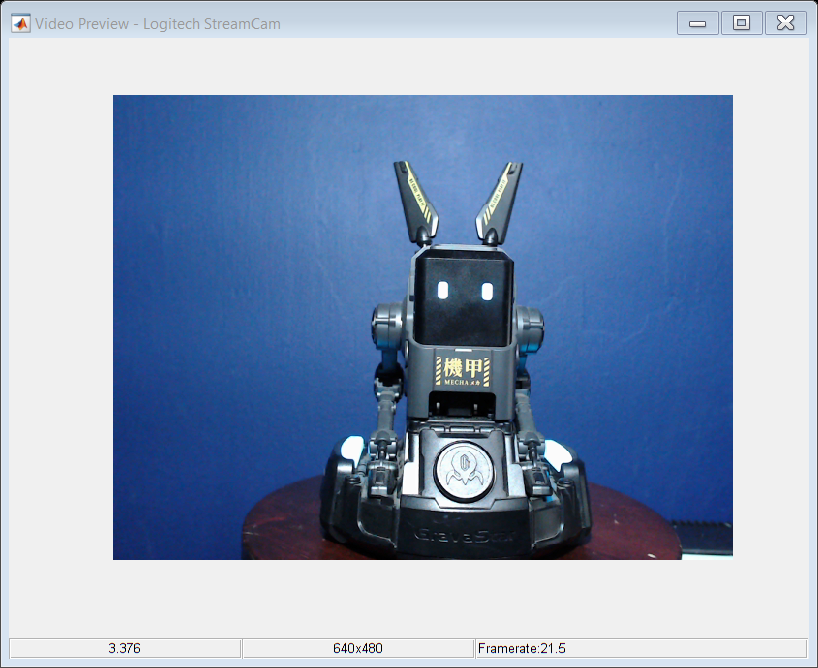

In [26]:
preview(camara_web)

In [27]:
closePreview(camara_web)

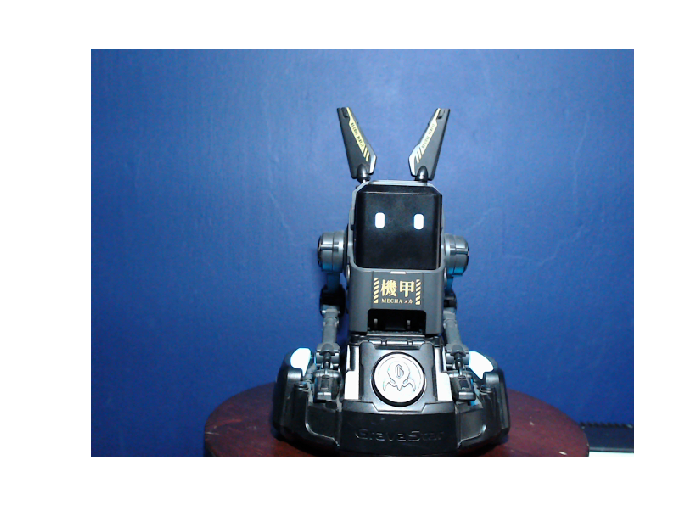

In [28]:
imagen = snapshot(camara_web);
figure
imshow(imagen)

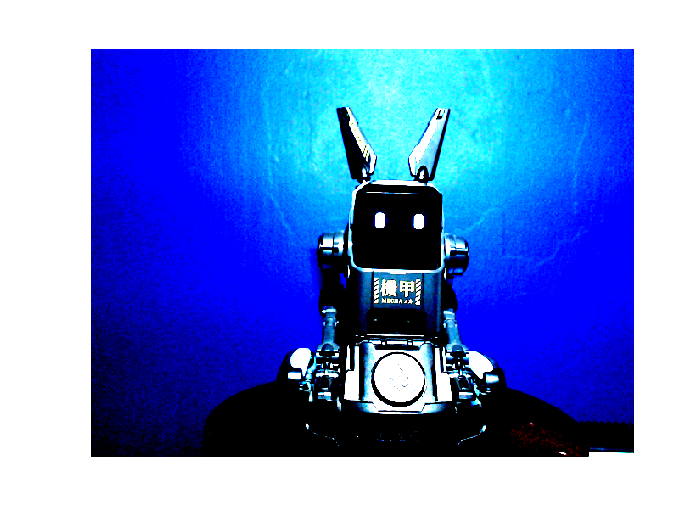

In [37]:
close all
imagen_ajustada_RGB=imadjust(imagen, [0.4 0.4 0.4; 0.6 0.6 0.6],[]);
imshow(imagen_ajustada_RGB)

Se puede mostrar la imagen en una gráfica donde se destaquen las intensidades de los tonos rojo verde y azul como se hizo en la práctica 13:

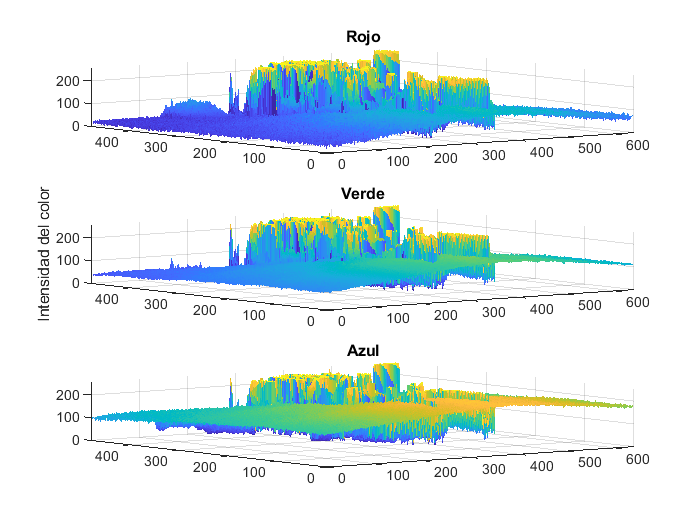

In [38]:
Rojo = imagen(:,:,1); 
Verde = imagen(:,:,2); %Descomposición de la intensidad de rojo, verde y azul de la imágen original
Azul = imagen(:,:,3);


[r,c,j]=size(imagen);% Se actualiza el tamaño de la imagen
 
figure
subplot(3,1,1)
surf(1:c,1:r,Rojo,'EdgeColor','none'); 
title("Rojo")
view(3)
subplot(3,1,2)   % Se grafican en formato de intensidad los colores
surf(1:c,1:r,Verde,'EdgeColor','none'); 
zlabel('Intensidad del color')
view(3)
title("Verde")
subplot(3,1,3)
surf(1:c,1:r,Azul,'EdgeColor','none'); 
title("Azul")
view(3)


Se muestra la imagen en formato de escala de pixeles

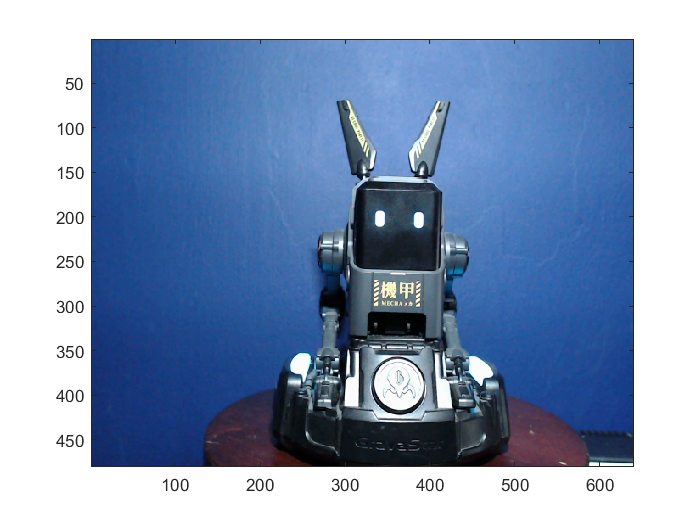

In [30]:
figure
image(imagen)

Finalmente, se limpia el objeto o variable cámara

In [31]:
clear('camara_web')

## Comunicación por puerto serie

Un bit es la unidad fundamental del sistema binario, el cual es la base de los sistemas digitales como lo son las coimputadoras, teléfonos, relojes, tablets y demás dispositivos denomindados inteligentes. El bit es  aquella entidad que puede asumir solo dos valores discretos, el uno y el cero lógico, para representar datos con diferente valor numérico o tipográfico, se usan combinaciones de un grupo de bits. Actualmente, la unidad de medida de información digital es el byte, que consta de ocho bits, es decir se pueden representar $2^8$ caracteres o combinaciones diferentes usando $8$ bits, en general se pueden representar $2^n$ caracteres usando $n$ bits. La información en el formato digital se codifica en conjuntos de unos y ceros que, cuando se intercambia entre dos o más sistemas digitales o entre un sistema digital y sus periféricos, se hace necesario el uso de cables o conexiones físicas para intercambiar los bits que conforman los datos digitales. Cuando se usa un cable para transmitir cada uno de los bits, que se convierten en  señales eléctricas que representan a los bits, se trata de un protocolo de comunicación paralelo. Este protocolo fue muy popular en las impresoras de las computadoras. 

```{figure} /images/com_paralelo.png
:height: 320px
:name: com_paralelo
Comunicación en modo paralelo.
```

El protocolo de comunicación paralelo es el más rápido debido a que las señales eléctricas se transmiten de manera directa de punto a punto, sin embargo, es necesario hacer uso de una cantidad considerable de cables que se traduce en un mayor espacio y complejidad en los circuitos impresos que se usan en los sistemas digitales. Una opción para transmitir datos es codificar la información de manera que se utilice un conjunto reducido de cables, esto se consigue transmitiendo un bit detrás de otro, separados por tiempos de aparción, duración y en un orden preciso. Cuando los datos se transmiten en este formato secuencial, se trata de un protocolo de comunicación serie.


El protocolo de comunicación serie es amplamente utilizado en un gran número de aplicaciones debido a que requiere un reducido número de líneas de comunicación entre los sistemas digitales que lo utilizan para compartir información. En el caso de las computadoras de escritorio y laptops los puertos que usan este protocolo son el puerto USB en todas sus versiones y el puerto PCIe. El puerto HDMI también usa el protocolo serie para intercambiar contenido multimedia. 

```{figure} /images/com_serie.png
:height: 320px
:name: com_serie
Comunicación en modo serie.
```

Actualmente, una gran parte de los equipos profesionales de adquisición de datos utilizan el puerto USB para transmitir granades cantidades de mediciones de señales provenientes de sensores usados en aplicaciones de experimentos para validar modelos y teorías, además de una amplia variedad de apliaciones al control de procesos. El protocolo de comunicación que utiliza el puerto USB es complicado por que permite una velocidad de transmisión considerable, actualmente de 40 Giga bits por segundo, esto quiere decir que se transmiten miles de millones de bits en un solo segundo.

Una alternativa mas sencilla para el intercambio de información entre una computadora y algún sistema digital como un microcontrolador o tarjeta Arduino, es el protocolo serie asíncrono. El protocolo serie asíncrono se especifica en los siguientes parámetros principales:

* Identificador de puerto: En el sistema operativo más comun se usa el formato "COMXX", donde COM alude a comunicación y XX es un entero que identifica el número de puerto, en sistemas operativos como linux el identificador es típicamente "dev/ttyXX".

* BaudRate: Determina la cantidad de bits que se transmiten de un sistema a otro en un segundo. Valores típicos son 9600, 115200 y en ocasiones especiales hasta 2000000.

* Bits de datos: Determina la cantidad de bits que contiene cada uno de los datos a transmitir. Usualmente se utizan 8 bits de datos como estandard, como ya se había mensionado, se trata de un byte.

* Bits de inicio y bits de fin de trama: Cada conjunto de datos se señaliza usando una combinación de bits que funciona como un encabezado y como un terminador de trama para que el sistema identifique cuando inicia un dato y cuando termina. Usualmente se utiliza un solo bit de inicio y uno de parada.
* Tiempo de espera: Se identifica como timeout, es el tiempo máximo que esperará el sistema digital a recibir una respuesta sin considerar un error de comunicación.
* Bit de paridad: se usa para detectar errores en la transmisión, usualmente indica si se envía una cantidad par de unos o de ceros para corroborar que el dato llegó completo. Normalmente se puede establecer transmisiones exitosas sin el uso de este bit.

Para ejemplificar el uso de la comunicación serie usaremos una tarjeta arduino conectada al puerto USB de la computadora, previa instalación de la interfaz de Arduino y los drivers necesarios para su uso y programación.

El código fuente para la tarjeta Arduino se encuentra en el siguiente repositorio GitHub

https://raw.githubusercontent.com/LuisGerardo2204/C-digo-Arduino/refs/heads/main/ESP32_simple_ADC.ino


```{figure} /images/ESP32_1ADC.png
:height: 300px
:name: esp32_ADC
Diagrama para lectura analógica con ESP32
```

```{figure} /images/ESP32_2ADC.png
:height: 320px
:name: esp32_2ADC
Diagrama para lectura analógica con ESP32.
```

https://raw.githubusercontent.com/LuisGerardo2204/C-digo-Arduino/refs/heads/main/ESP32_dos_ADC.ino


## Adquisición y graficación de datos 




ans = "COM9"

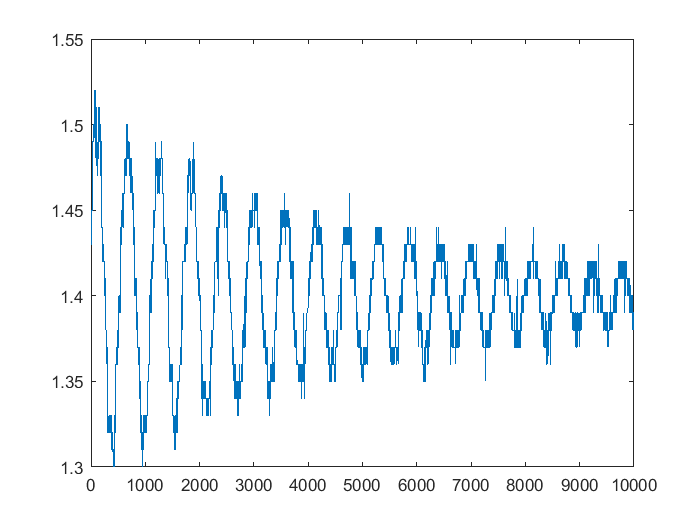

In [53]:
clear
close all
delete(serialportfind);
serialportlist("all")
s = serialport("COM9",115200,"Timeout",5);
configureTerminator(s,"LF")
flush(s);
datos=[];
for i=1:10000
    %pause(0.01)
  datos=[datos str2double(readline(s))];
  
end 


clear s

plot(datos)

comunicacion con dos canales


ans = "COM9"

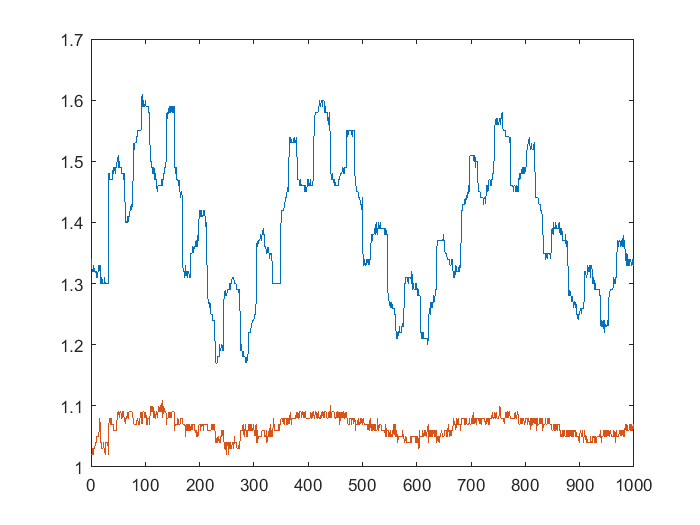

In [9]:
clear
close all
delete(serialportfind);
serialportlist("all")
s = serialport("COM9",115200,"Timeout",5);
configureTerminator(s,"LF")
flush(s);
datos=[];
for i=1:1000
    %pause(0.01)
  %datos=[datos str2double(readline(s))];
  datos=[datos readline(s)];
end 
canales =  split(datos,",");
canal_a=str2double(canales(:,:,1));
canal_b=str2double(canales(:,:,2));
clear s

plot(canal_a)
hold on
plot(canal_b)

## Gracicación en tiempo real no estricto


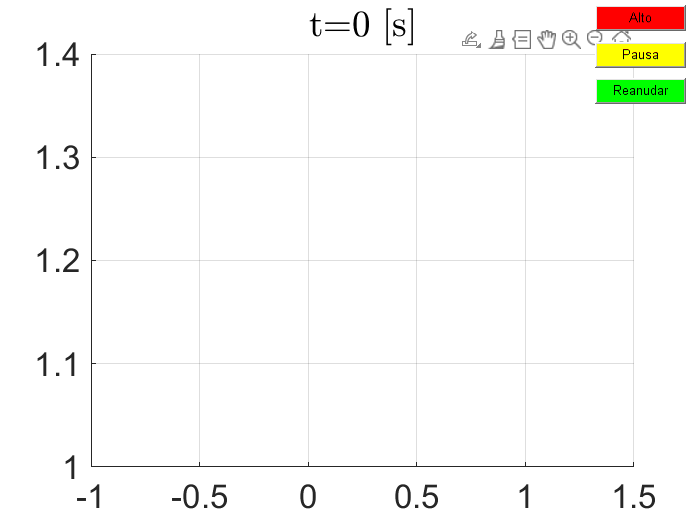

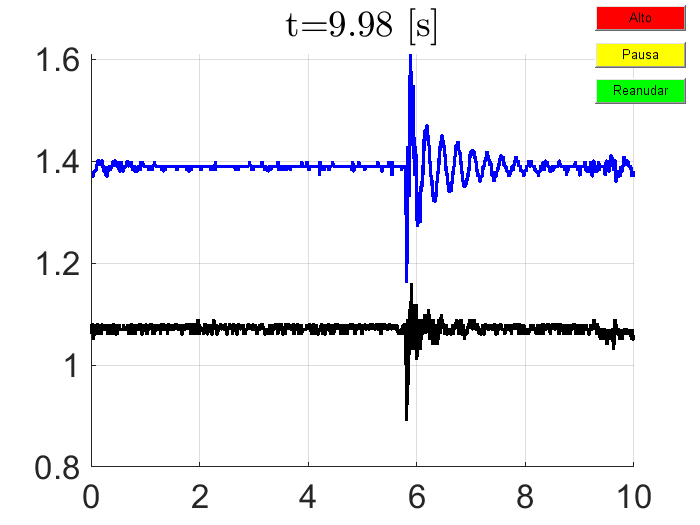

In [76]:
clear 
close all
clc

delete(serialportfind);
%serialportlist("all")
s = serialport("COM9",115200,"Timeout",5);
configureTerminator(s,"LF")

datos=[];
canales=[];
canal_a=[];
canal_b=[];
muestra=[];

% Creación del vector de tiempo
t=0:0.001:6;

uno=figure;
a=axes;
grid
hold on


%Se generan botones de control de animación especificndo su texto posición y color de fondo
  handle=uicontrol('style','pushbutton','units','normal','backgroundcolor','red','position', ...
            [0.85 .94 .13 .05],'String','Alto','callback','global stopstop;stopstop=1;'); 
 % Se da formato al texto de los ejes de las gráficas   
  handle2=uicontrol('style','pushbutton','units','normal','backgroundcolor','yellow','position', ...
            [0.85 .87 .13 .05],'String','Pausa','callback','global ppause;ppause=1;');
  handle3=uicontrol('style','pushbutton','units','normal','backgroundcolor','green','position', ...
            [0.85 .8 .13 .05],'String','Reanudar','callback','global ppause;ppause=0;');
set(gca,'defaulttextinterpreter','latex')
  

 
set(gca,'fontsize',20);
set(gca,'fontname','Arial','FontWeight','normal');  

global stopstop ppause;
ppause=0;
i=1;
stopstop =0;
% La animación se repetirá para cada valor de la función x(t) en cada instante de tiempo 
flush(s); 
while( i<1000&&stopstop==0)

  cla

   datos=[datos readline(s)];
   muestra=[muestra i];

   canales=split(datos(i),",");
   canal_a(i)=str2double(canales(1));
   canal_b(i)=str2double(canales(2));
  
     
     cla
     title(strcat('t= ',num2str((i-1)*0.01),' [s]'))
     plot(muestra(1:i)*0.01,canal_a(1:i),'b -','LineWidth',2)
     plot(muestra(1:i)*0.01,canal_b(1:i),'k -','LineWidth',2)
     pause(0.0001)
     
           while ppause==1
                    pause(.001)%Acción del botón de pausa
                  
            end
       i=i+1;       
       cla %pausa para animación
                    
end
    
clear s

plot(muestra*0.01,canal_a,'b -','LineWidth',2)
hold on
plot(muestra*0.01,canal_b,'k -','LineWidth',2)


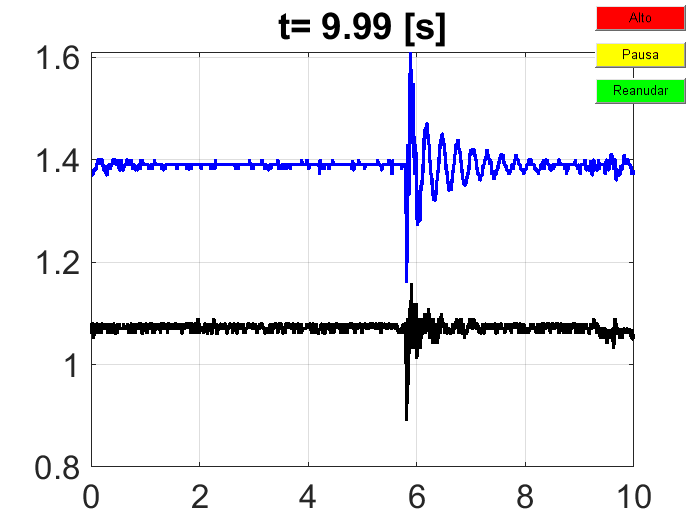

In [80]:
close all
figure



handle=uicontrol('style','pushbutton','units','normal','backgroundcolor','red','position', ...
            [0.85 .94 .13 .05],'String','Alto','callback','global stopstop;stopstop=1;'); 
 % Se da formato al texto de los ejes de las gráficas   
  handle2=uicontrol('style','pushbutton','units','normal','backgroundcolor','yellow','position', ...
            [0.85 .87 .13 .05],'String','Pausa','callback','global ppause;ppause=1;');
  handle3=uicontrol('style','pushbutton','units','normal','backgroundcolor','green','position', ...
            [0.85 .8 .13 .05],'String','Reanudar','callback','global ppause;ppause=0;');
  



plot(muestra*0.01,canal_a,'b -','LineWidth',2)
set(gca,'fontsize',20);
set(gca,'fontname','Arial','FontWeight','normal');  
title("t= "+num2str((i-1)*0.01)+" [s]")
grid
hold on
plot(muestra*0.01,canal_b,'k -','LineWidth',2)


## Encendido de relevadores via puerto serie
https://raw.githubusercontent.com/LuisGerardo2204/C-digo-Arduino/refs/heads/main/ESP32_relays_serie.ino

In [82]:
% Programa de ejemplo de aplicación de la función menú

clear
close all
clc

delete(serialportfind);
serialportlist("all")
s = serialport("COM9",115200,"Timeout",5);
configureTerminator(s,"LF")
flush(s); 
salir=0;
while salir==0
relay=menu("Control remoto","Encender relay 1","Apagar relay 1","Encender relay 2"...
    ,"Apagar relay 2","Encender relay 3","Apagar relay 3","Encender relay 4","Apagar relay 4",...
    "Encender todos","Apagar todos","Salir");

switch relay

       case 1
       write(s,"A","uint8")  
       case 2
       write(s,"B","uint8")   
       case 3
       write(s,"C","uint8")  
       case 4
       write(s,"D","uint8")   
       case 5
       write(s,"E","uint8")  
       case 6
       write(s,"F","uint8")  
       case 7
       write(s,"G","uint8")
       case 8
       write(s,"H","uint8")    
       case 9
       write(s,"I","uint8")  
       case 10
       write(s,"J","uint8") 
       case 11
       salir=1;
end


end

clear s

ans = "COM9"

## Comunicación mediante el protocolo UDP

Una alternativa para la comiunicación, que aprovecha la infraestructura de la red de area local es el protocolo UDP. El protocolo UDP utiliza una dirección ip, un pueto de escucha y un puerto de escritura. Es un protocolo menos robusto que el protocolo TCP-IP, pero es muy utilizado debido a su sencillez y portabilidad.

```{figure} /images/UDP.png
:height: 300px
:name: com_UDP
Protocolo de comunicación UDP.
```

```{figure} /images/ESP32_bb.png
:height: 320px
:name: esp32_UDP
Diagrama para conmutación de leds con protocolo UDP.
```
https://raw.githubusercontent.com/LuisGerardo2204/C-digo-Arduino/refs/heads/main/ESP32UDP.ino

In [86]:
clear
close all
clc
u = udpport("IPV4")
write(u,"E1","uint8","192.168.0.25",2020);
pause(1)
write(u,"E2","uint8","192.168.0.25",2020);
pause(1)
write(u,"E3","uint8","192.168.0.25",2020);
pause(1)
write(u,"E4","uint8","192.168.0.25",2020);
pause(2)
write(u,"A1","uint8","192.168.0.25",2020);
pause(1)
write(u,"A2","uint8","192.168.0.25",2020);
pause(1)
write(u,"A3","uint8","192.168.0.25",2020);
pause(1)
write(u,"A4","uint8","192.168.0.25",2020);
pause(1)


u = 
  UDPPort with properties:

     IPAddressVersion: "IPV4"
            LocalHost: "0.0.0.0"
            LocalPort: 50548
                  Tag: ""
    NumBytesAvailable: 0

  Show all properties, functions

In [2]:
write(u,"Et","uint8","192.168.0.25",2020);
pause(2)
write(u,"At","uint8","192.168.0.25",2020);
pause(2)
write(u,"Et","uint8","192.168.0.25",2020);
pause(2)
write(u,"At","uint8","192.168.0.25",2020);

data = read(u,15,"uint8")
clear u

data = 1×15 double
   108   108   101   103    97   114   111   110    32    50    32    98   121   116   101

## Encendido de relevadores via protocolo UDP

In [90]:
% Programa de ejemplo de aplicación de la función menú y el protocolo UDP

clear
close all
clc

clear
close all
clc
u = udpport("IPV4")

salir=0;
while salir==0
relay=menu("Control remoto","Encender relay 1","Apagar relay 1","Encender relay 2"...
    ,"Apagar relay 2","Encender relay 3","Apagar relay 3","Encender relay 4","Apagar relay 4",...
    "Encender todos","Apagar todos","Salir");

switch relay

       case 1
         write(u,"E1","uint8","192.168.0.25",2020);
       case 2
         write(u,"A1","uint8","192.168.0.25",2020); 
       case 3
         write(u,"E2","uint8","192.168.0.25",2020);
       case 4
         write(u,"A2","uint8","192.168.0.25",2020);   
       case 5
         write(u,"E3","uint8","192.168.0.25",2020);
       case 6
         write(u,"A3","uint8","192.168.0.25",2020); 
       case 7
         write(u,"E4","uint8","192.168.0.25",2020);
       case 8
         write(u,"A4","uint8","192.168.0.25",2020);   
       case 9
         write(u,"Et","uint8","192.168.0.25",2020);
       case 10
         write(u,"At","uint8","192.168.0.25",2020);
       case 11
       salir=1;
end
end

clear s

u = 
  UDPPort with properties:

     IPAddressVersion: "IPV4"
            LocalHost: "0.0.0.0"
            LocalPort: 60252
                  Tag: ""
    NumBytesAvailable: 0

  Show all properties, functions

# Ejercicio de la práctica 16

1. Escriba un programa que permita el acceso a una cámara ip de libre visualización, muestre la vista previa de la cámara, realice una captura y haga las siguientes operaciones con la imagen captura:


a) En otra figura muestre la imagen original y su versión en el formato HSV con el factor 0.85 aplicado a la matriz de color o matiz.

c) En una tercer figura muestre la imagen original y la figura con la siguientes transformaciones:

$$
Y= 0.5R+0.2G+0.75B,~~~~I=-0.8R-0.4,3.5G-0.4B,~~~~~Q=0.707R+0.52G-0.62B
$$

donde $R$ es la matriz componente rojo, $B$ es la matriz componente azul y $G$ es la matriz componente verde. Use el comando `imshow(cat(3,Y,I,Q))` para mostrar la imagen transformada.

2. Realice una captura con una camara web y ajuste el contraste usando la instrucción `imadjust(I,[minR minG minB;maxR maxG maxB],[])` con los siguientes parámetros: minR=0.3, minG=0.25 minB=0.45, maxR=0.67, maxG=0.68 y maxB=0.62.

3. Escriba un programa que permita capturar 100 muestras de uno de los canales analógicos de una tarjeta conectada al puerto serie y realice las siguientes operaciones con los datos:

    a) Reste el promedio de todos los datos a cada uno de los datos adquridos (datos_nuevo=datos -mean(datos)) y   alamacénelos en una variable. 

    b) Encuentre la desviación estandard de los datos.

   
    c) Encuentre el máximo y el mínimo de los datos.

   
    d) En una figura independiente, grafique los datos originales contra el tiempo y los datos a los que se les ha restado el promedio contra el tiempo.

5. Escriba un programa que despliegue un menú tal que funcione como un control remoto que permita encender 4 relevadores o diodos LED. Puede usar el protocolo serie si utiliza una tarjeta Arduino basada en atmega o, de manera opcional, el protocolo UDP si tiene disponible una tarjeta ESP32.  